In [ ]:
from mlscratch.svm import SVMHardMargin, SVMSoftMargin, SVM
import matplotlib.pyplot as plt

# Hard margin

In [2]:
import numpy as np

def make_separable(n=100, dim=2, gap=4.0, seed=0):
    rng = np.random.default_rng(seed)
    half = n // 2
    # two clusters offset along a random direction by `gap`
    direction = rng.standard_normal(dim)
    direction /= np.linalg.norm(direction)
    offset = gap * direction

    X_pos = rng.standard_normal((half, dim)) + offset
    X_neg = rng.standard_normal((half, dim)) - offset

    X = np.vstack([X_pos, X_neg]).astype(np.float64)
    y = np.concatenate([np.ones(half), -np.ones(half)]).astype(np.float64)

    # shuffle so the classes aren't blocked
    perm = rng.permutation(n)
    return X[perm], y[perm]

In [3]:
X, y= make_separable()

clf = SVMHardMargin()
clf.fit(X, y)

pred = clf.predict(X)
acc = (pred == y).mean()
acc

np.float64(1.0)

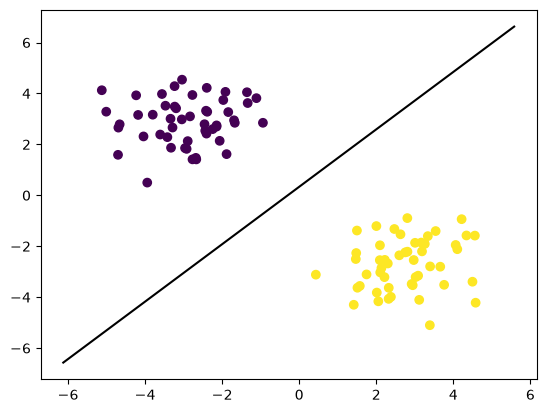

In [4]:
plt.scatter(X[:,0], X[:,1], label="", marker="o", c =y)
x1 = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 200)
plt.plot(x1, (-clf.b -clf.w[0] * x1)/clf.w[1], "k-")



# Soft Margin

In [5]:
def make_overlapping(n=200, dim=2, gap=1.0, spread=1.0, seed=0):
    rng = np.random.default_rng(seed)
    half = n // 2
    direction = rng.standard_normal(dim)
    direction /= np.linalg.norm(direction)
    offset = gap * direction

    X_pos = spread * rng.standard_normal((half, dim)) + offset
    X_neg = spread * rng.standard_normal((half, dim)) - offset

    X = np.vstack([X_pos, X_neg]).astype(np.float64)
    y = np.concatenate([np.ones(half), -np.ones(half)]).astype(np.float64)

    perm = rng.permutation(n)
    return X[perm], y[perm]

In [6]:
X, y = make_overlapping()

clf = SVMSoftMargin()
clf.fit(X, y)


In [7]:
pred = clf.predict(X)

acc = (pred ==y).mean()
acc

np.float64(0.845)

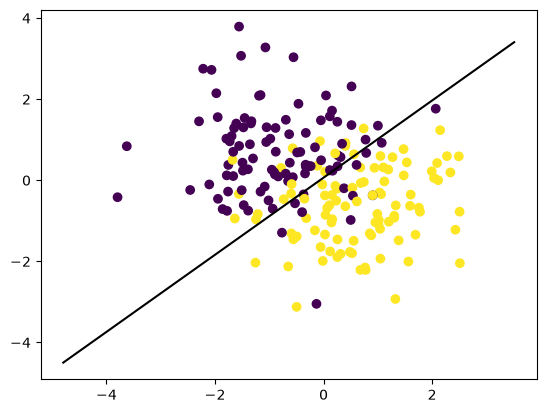

In [8]:
plt.scatter(X[:,0], X[:,1], label="", marker="o", c =y)
x1 = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 200)
plt.plot(x1, (-clf.b -clf.w[0] * x1)/clf.w[1], "k-")

# Dual Problem using the RBF Kernel for Non-Linearly Separable data

In [9]:
def make_circles(n=200, noise=0.1, factor=0.3, seed=0):
    """Two concentric rings"""
    rng = np.random.default_rng(seed)
    half = n // 2

    # outer ring, radius ~1
    t_out = rng.uniform(0, 2 * np.pi, half)
    X_out = np.c_[np.cos(t_out), np.sin(t_out)]

    # inner ring, radius = factor
    t_in = rng.uniform(0, 2 * np.pi, half)
    X_in = factor * np.c_[np.cos(t_in), np.sin(t_in)]

    X = np.vstack([X_out, X_in]) + noise * rng.standard_normal((n, 2))
    y = np.concatenate([np.ones(half), -np.ones(half)])       # outer +1, inner -1

    perm = rng.permutation(n)
    return X[perm].astype(np.float64), y[perm].astype(np.float64)

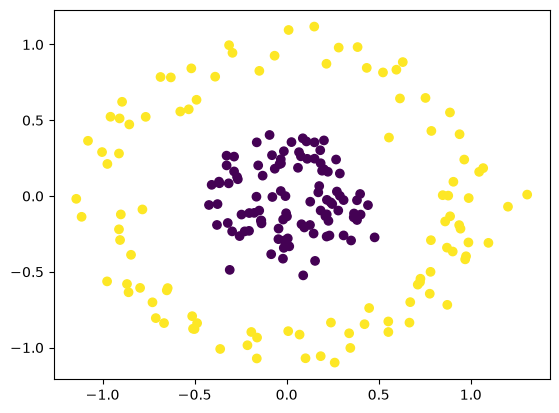

In [10]:
X, y = make_circles()

plt.scatter(X[:,0], X[:,1],c = y)

In [11]:
clf_dual = SVM()
clf_dual.fit_linear(X, y)

In [12]:
pred_lin = clf_dual.predict_linear(X)
acc = (y == pred_lin).mean()
acc

np.float64(0.72)

In [13]:
clf_rbf = SVM()
clf_rbf.fit_RBF(X,y)

In [15]:
pred = clf_rbf.predict_RBF(X)
acc = (pred == y).mean()

In [ ]:
acc

np.float64(1.0)

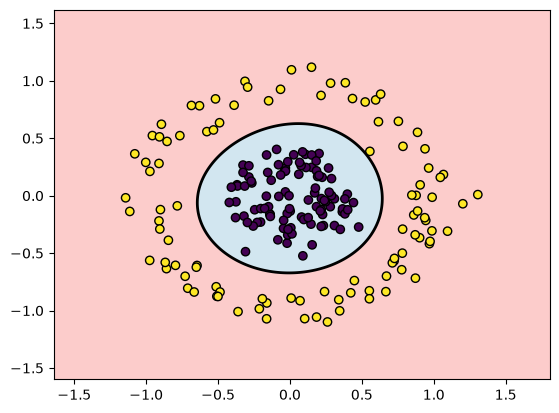

In [ ]:
x1_min, x1_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
x2_min, x2_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x1_min, x1_max, 300), np.linspace(x2_min, x2_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

scores = clf_rbf._rbf(grid, clf_rbf.X_train) @ (clf_rbf.alpha * clf_rbf.y_train) + clf_rbf.b
zz = scores.reshape(xx.shape)

plt.contourf(xx, yy, zz, levels=[zz.min(), 0, zz.max()], colors=["#a6cee3", "#fb9a99"], alpha=0.5)
plt.contour(xx, yy, zz, levels=[0], colors="k", linewidths=2)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors="k")